## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=1.5

fpeak=7; dt=0.003; nt=1000

ntr=201

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

nzsnap=249; nxsnap=249; nsnap=51
def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

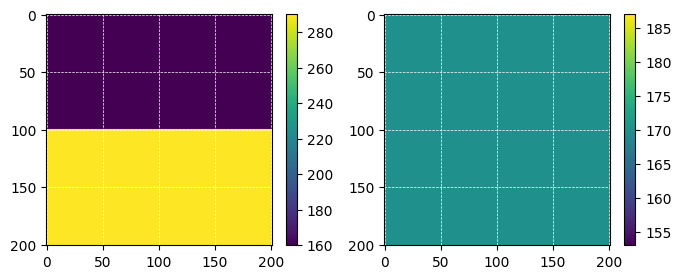

In [29]:
# True
!makevel nz=100 nx=$nx v000=160 > c1
!makevel nz=101 nx=$nx v000=290 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nx > cel
!rm c1 c2 tmp
#density=0.4*np.pi
!makevel nz=$nz nx=$nx v000=1.25663708 > one
!cat cel one > true

# Background
!makevel nz=$nz nx=$nx v000=170 > cel
!cat cel one > init

#plot
plt.figure(figsize=(8,3))
true=read('true',(2*nx,nz))
init=read('init',(2*nx,nz))
plt.subplot(1,2,1); imshow(true[:,:nx])
plt.subplot(1,2,2); imshow(init[:,:nx])

In [3]:
#topo
!makevel nz=1   nx=$nx v000=75  > topo

In [28]:
%%writefile setup_default

MODEL_SIZE              '201 201 1'
MODEL_SPACING           '1.5 1.5 1'
FILE_MODEL               true
MODEL_ATTRIBUTES        'vp rho'
#FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '75 75  0'
FR                      '75  0  0'
DR                      '0  1.5 0'
NR                      201

SU_SCALCO   -10

SCOMP                   p
RCOMP                   p #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IS_FREESURFACE  F

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           1000
DT           0.003
FPEAK        7

SNAPSHOT        'p vz vx'
#NSNAPSHOT    50


## for inversion ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'
WEIGHTING           'none'

PARAMETER           'vp:160:290'

SMOOTHING     'none'
#PRECO         'z^0'


#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

JOB           'ls'

IF_USE_CHECKPOINT   F

Overwriting setup_default


In [5]:
!make

#System
(cd ../../Modules/System; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/System'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/System'
#Etc
(cd ../../Modules/Etc; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Etc'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Etc'
#Signal
(cd ../../Modules/Signal; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Signal'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Signal'
#Modeling
(cd ../../Modules/Modeling; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Modeling'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Modeling'
#Kernel
(cd ../../Modules/Kernel; make App=FWI)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Kernel'
m_parametrizer_velocities-densi

## AC

### p-p

#### Obs & Syn data

In [35]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/FWD')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Bureau/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 joey joey 15 Jun 25 00:08 ../../exe/FWD -> fwd_AC_FDSG_O4_
 Git Commit: b09c73c
 Git Branch: DAS
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 00:08:55
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D

In [37]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/FWD')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Bureau/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 joey joey 15 Jun 25 00:08 ../../exe/FWD -> fwd_AC_FDSG_O4_
 Git Commit: b09c73c
 Git Branch: DAS
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 00:09:07
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D

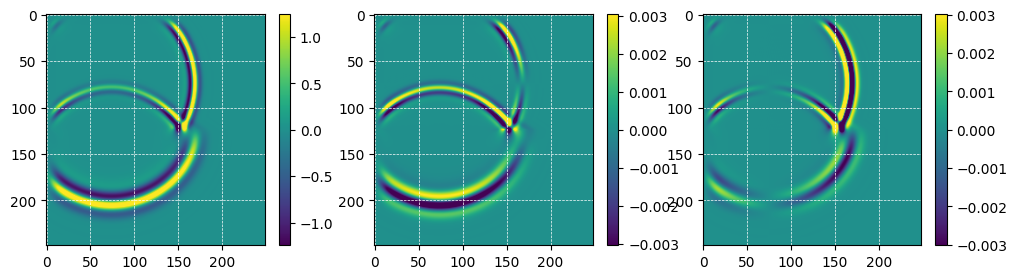

In [36]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_obs/snap_fld_u%p' ,(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_obs/snap_fld_u%vz',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_obs/snap_fld_u%vx',(51,249,249)),perc=98)

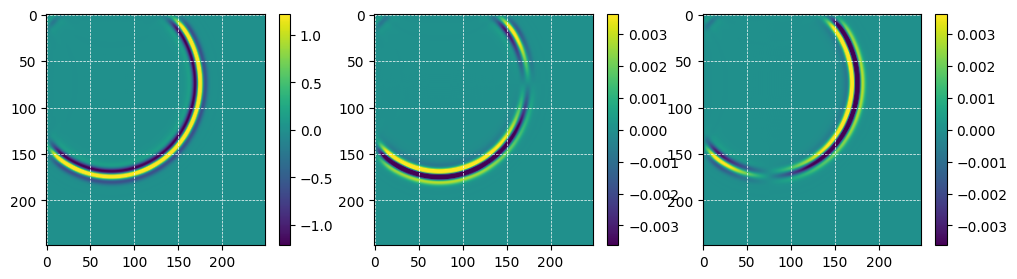

In [38]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read_snap('results_syn/snap_fld_u%p' ,(51,249,249)),perc=98)
plt.subplot(1,3,2); imshow(read_snap('results_syn/snap_fld_u%vz',(51,249,249)),perc=98)
plt.subplot(1,3,3); imshow(read_snap('results_syn/snap_fld_u%vx',(51,249,249)),perc=98)

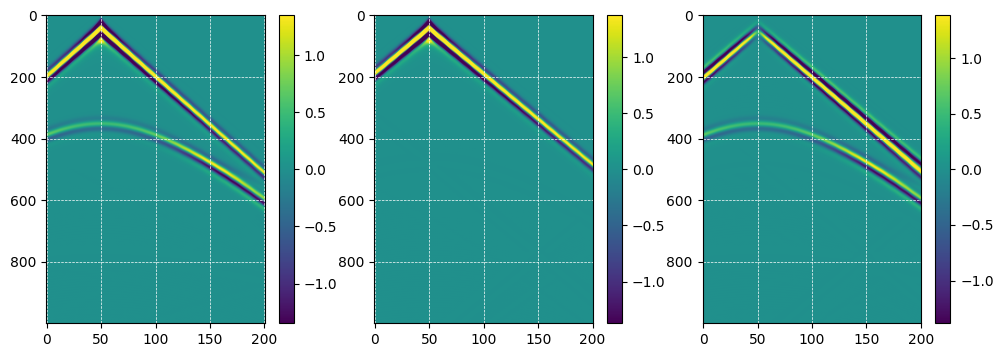

In [40]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su')-read_su('results_syn/Ru_Shot0001.su'),perc=98)

In [41]:
!make

#System
(cd ../../Modules/System; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/System'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/System'
#Etc
(cd ../../Modules/Etc; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Etc'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Etc'
#Signal
(cd ../../Modules/Signal; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Signal'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Signal'
#Modeling
(cd ../../Modules/Modeling; make)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Modeling'

make[1]: Leaving directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Modeling'
#Kernel
(cd ../../Modules/Kernel; make App=FWI)
make[1]: Entering directory '/home/joey/Desktop/SeisJIMU_AC/SeisJIMU/Modules/Kernel'
m_empirical.f90 m_parametrizer_

#### Gradient

In [53]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Bureau/SeisJIMU_AC/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 joey joey 42 Jun 25 00:29 ../../exe/GradientTest -> gradienttest_AC_FDSG_O4_velocities-density
 Git Commit: b09c73c
 Git Branch: DAS
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/25/2026
System time: 00:29:43
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|

 it----        2000
 fld_u minmax values:  -1.65780497E-12   1.10678415E-12
 Elapsed time to add stress source     2.92462111E-03
 Elapsed time to update stresses      0.242782235    
 Elapsed time to add source stresses   5.86688519E-04
 Elapsed time to update velocities    0.262386680    
 Elapsed time to extract field         9.07826424E-03
 Elapsed time to save boundary         8.15778971E-03
 Total elapsed time (min):   8.76527093E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_sfield%*  n1=249 perc=99
 xmovie < snap_sfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g
 DATA_FORMAT is NOT found, take default: su
 Found proper SU scalel = 1.00000000
 SU_SCALEL is NOT found, take default: 1.00000000
 Found proper SU scalco = 1.00000000
 SU_SCALCO is NOT found, take default: 1.00000000
 SU data write success.
 JOB is NOT found, take 0, '' or F
 IF_BLOOM : F
 UPDATE_WAVELET is NOT found, take 0, '' or F
 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI

 it----        1500
 fld_a minmax values:  -5.17138197E-20   5.37876197E-20
 fld_u minmax values:  -3.87049377E-12   3.64499273E-12
 it----        1000
 fld_a minmax values:  -5.91178705E-18   5.27818035E-18
 fld_u minmax values:  -8.14035617E-10   7.29086291E-10
 it----         500
 fld_a minmax values:  -5.93693929E-17   3.94218332E-17
 fld_u minmax values:  -1.22117549E-09   1.07677445E-09
 Elapsed time to load boundary            1.96630955E-02
 Elapsed time to update velocities       0.212284565    
 Elapsed time to rm source velocities     2.08425522E-03
 Elapsed time to update stresses         0.223885536    
 Elapsed time to rm source stresses       2.07209587E-03
 Total elapsed time for forward (min)   7.66649237E-03
  ---------------------------- 
 Elapsed time to add adjsource velocities    7.18832016E-03
 Elapsed time to update adj velocities      0.211976767    
 Elapsed time to add adjsource stresses      8.20875168E-03
 Elapsed time to update adj stresses        0.247708

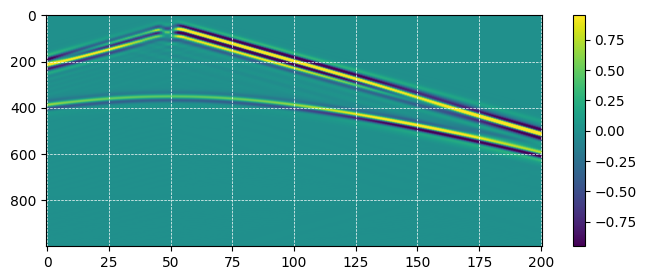

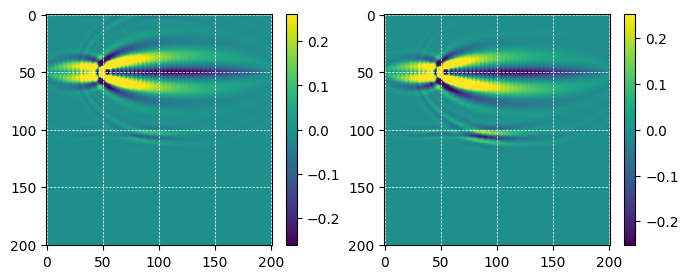

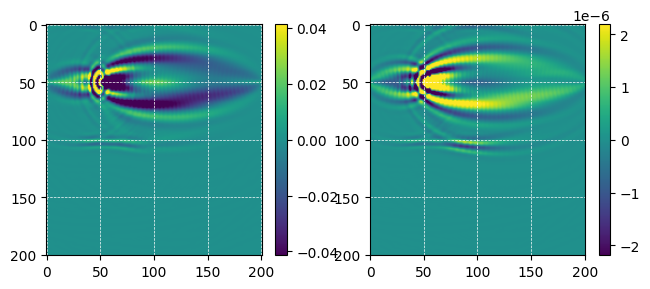

In [56]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results/qp0%g'), perc=98)
plt.subplot(1,2,2); imshow(read('results/qp0%pg'),perc=98)


corr=read('results/correlate_gradient',n=(2*nx,nz))
grho=corr[:,:nx]
gkpa=corr[:,nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(grho,perc=98)
plt.subplot(1,4,2); imshow(gkpa,perc=98)

#### gradienttest_AC_FDSG_O4_velocities-density on gvp

In [57]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   10.9499540       10.9502678      -31.3758850      -32.0481758       1.02142704     T
 1st cond   9.99999975E-05   10.9472094       10.9502678      -30.5843353      -32.0481758       1.04786241     T
 1st cond   1.00000005E-03   10.9193554       10.9502678      -30.9123974      -32.0481758       1.03674185     T
 1st cond   9.99999978E-03   10.6445103       10.9502678      -30.5757523      -32.0481758       1.04815662     T
 1st cond  0.100000001       8.28432560       10.9502678      -26.6594219      -32.0481758       1.20213318     T
 1st cond   1.00000000       4.98375607       10.9502678      -5.96651173      -32.0481758       5.37134218     T


In [58]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond  -9.99999975E-06   10.9505882       10.9502678      -32.0434570      -32.0481758       1.00014722     F
 1st cond  -9.99999975E-05   10.9533768       10.9502678      -31.0897827      -32.0481758       1.03082657     F
 1st cond  -1.00000005E-03   10.9812937       10.9502678      -31.0258846      -32.0481758       1.03294957     F
 1st cond  -9.99999978E-03   11.2631292       10.9502678      -31.2861443      -32.0481758       1.02435684     F
 1st cond -0.100000001       14.3692827       10.9502678      -34.1901474      -32.0481758      0.937351227     F
 1st cond  -1.00000000       51.1952324       10.9502678      -40.2449646      -32.0481758      0.796327591     F


#### gradienttest_AC_FDSG_O4_velocities-density on grho

In [60]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "PARAMETER   'rho:1.25663708:2' " >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/GradientTest  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   10726.9629       10735.2822      -831933.625      -4070698.00       4.89305639     T
 1st cond   9.99999975E-05   10652.6436       10735.2822      -826386.750      -4070698.00       4.92589951     T
 1st cond   1.00000005E-03   9999.99609       10735.2822      -735286.125      -4070698.00       5.53620958     T
 1st cond   9.99999978E-03   9416.55371       10735.2822      -131872.859      -4070698.00       30.8683529     T
 1st cond  0.100000001       12804.2568       10735.2822       20689.7461      -4070698.00      -196.749542     F
 1st cond   1.00000000       18412.0156       10735.2822       7676.73340      -4070698.00      -530.264343     F
